<a href="https://colab.research.google.com/github/Deepanshusemwal10/ML-BASIC-/blob/main/MLLAB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
data = yf.download("AAPL",start ="2018-01-01" ,end = "2026-02-09" )

/tmp/ipython-input-674794252.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL",start ="2018-01-01" ,end = "2026-02-09" )
[*********************100%***********************]  1 of 1 completed


In [ ]:
print(data.tail(10))

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-01-26  255.410004  256.559998  249.800003  251.479996  55969200
2026-01-27  258.269989  261.950012  258.209991  259.170013  49648300
2026-01-28  256.440002  258.859985  254.509995  257.649994  41288000
2026-01-29  258.279999  259.649994  254.410004  258.000000  67253000
2026-01-30  259.480011  261.899994  252.179993  255.169998  92443400
2026-02-02  270.010010  270.489990  259.209991  260.029999  73913400
2026-02-03  269.480011  271.880005  267.609985  269.200012  64394700
2026-02-04  276.489990  278.950012  272.290009  272.290009  90545700
2026-02-05  275.910004  279.500000  273.230011  278.130005  52977400
2026-02-06  278.119995  280.910004  276.929993  277.119995  50420700


In [ ]:
data.isna().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [ ]:
df = data.copy()
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.341885,40.351254,39.639309,39.850084,102223600
2018-01-03,40.334866,40.878192,40.271636,40.405124,118071600
2018-01-04,40.522209,40.625254,40.299728,40.407454,89738400
2018-01-05,40.983578,41.070228,40.526904,40.618239,94640000
2018-01-08,40.831356,41.126437,40.732992,40.831356,82271200
...,...,...,...,...,...
2026-02-02,270.010010,270.489990,259.209991,260.029999,73913400
2026-02-03,269.480011,271.880005,267.609985,269.200012,64394700


In [ ]:
df ['Lag1']= df['Close'].shift(1)
df ['Lag2']= df['Close'].shift(2)
df ['Lag3']= df['Close'].shift(3)
df.dropna(inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,Lag1,Lag2,Lag3
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2018-01-05,40.983578,41.070228,40.526904,40.618239,94640000,40.522209,40.334866,40.341885
2018-01-08,40.831356,41.126437,40.732992,40.831356,82271200,40.983578,40.522209,40.334866
2018-01-09,40.826683,40.997642,40.611227,40.878206,86336000,40.831356,40.983578,40.522209
2018-01-10,40.817299,40.819643,40.515193,40.552665,95839600,40.826683,40.831356,40.983578
2018-01-11,41.049149,41.098330,40.864139,40.887556,74670800,40.817299,40.826683,40.831356


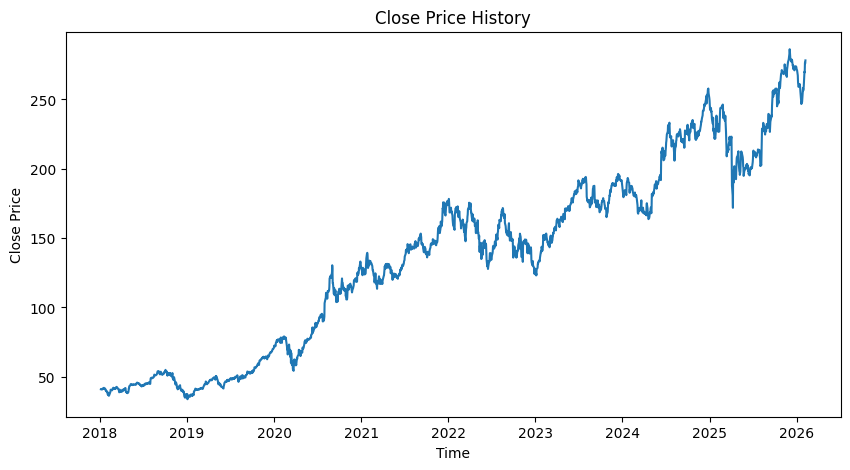

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Close Price History')
plt.show()

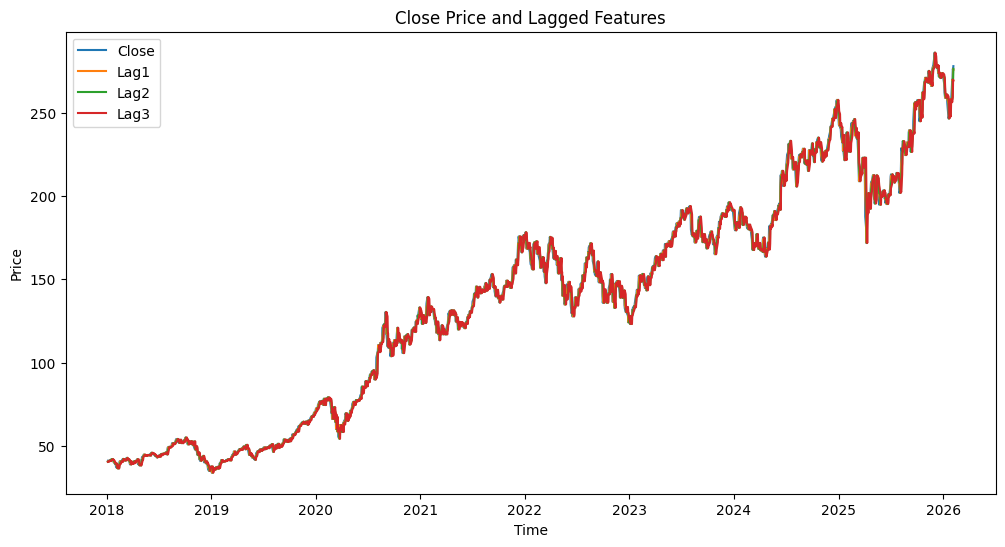

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['Lag1'], label='Lag1')
plt.plot(df['Lag2'], label='Lag2')
plt.plot(df['Lag3'], label='Lag3')

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Close Price and Lagged Features")
plt.legend()
plt.show()


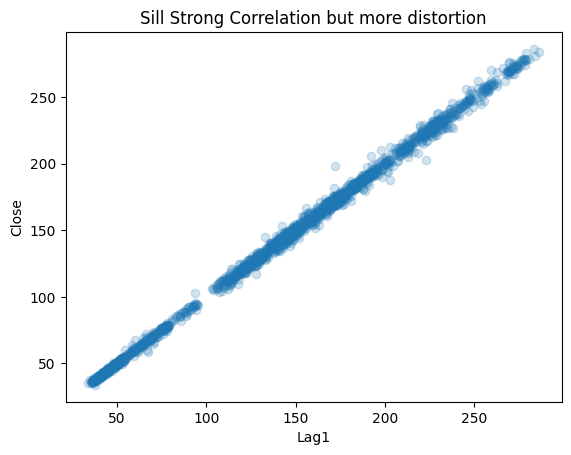

In [ ]:
plt.scatter(df['Lag1'], df['Close'], alpha=0.2)

plt.xlabel("Lag1")
plt.ylabel("Close")
plt.title("Sill Strong Correlation but more distortion")
plt.show()

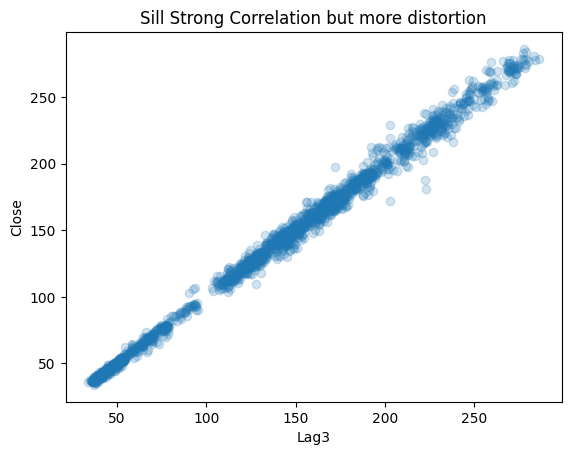

In [ ]:
plt.scatter(df['Lag3'], df['Close'], alpha=0.2)

plt.xlabel("Lag3")
plt.ylabel("Close")
plt.title("Sill Strong Correlation but more distortion")
plt.show()

In [ ]:
X= df[['Lag1','Lag2','Lag3']]
y= df['Close']
X


Price,Lag1,Lag2,Lag3
Ticker,,,
Date,,,
2018-01-05,40.522209,40.334866,40.341885
2018-01-08,40.983578,40.522209,40.334866
2018-01-09,40.831356,40.983578,40.522209
2018-01-10,40.826683,40.831356,40.983578
2018-01-11,40.817299,40.826683,40.831356
...,...,...,...
2026-02-02,259.480011,258.279999,256.440002
2026-02-03,270.010010,259.480011,258.279999


In [ ]:
X= df[['Lag1','Lag2','Lag3']]
Y= df['Close']
Y

Ticker,AAPL
Date,
2018-01-05,40.983578
2018-01-08,40.831356
2018-01-09,40.826683
2018-01-10,40.817299
2018-01-11,41.049149
...,...
2026-02-02,270.010010
2026-02-03,269.480011
2026-02-04,276.489990


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
Y_pred = model.predict(X_test)

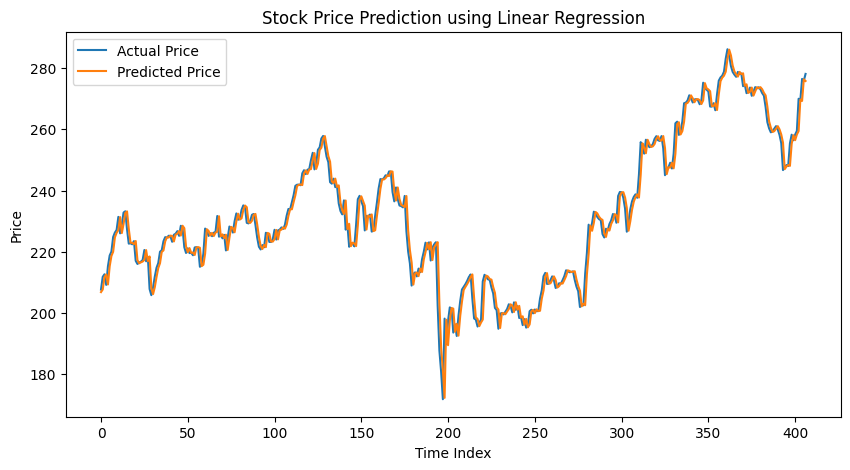

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(Y_pred, label='Predicted Price')

plt.legend()
plt.title("Stock Price Prediction using Linear Regression")
plt.xlabel("Time Index")
plt.ylabel("Price")

plt.show()